### Dataset: Energy Efficiency with HL (heating load) as target

In [2]:
from ucimlrepo import fetch_ucirepo

energy_efficiency = fetch_ucirepo(id=242) 
  
X = energy_efficiency.data.features 
y = energy_efficiency.data.targets

var_df = energy_efficiency.variables
col_map = dict(zip(var_df["name"], var_df["description"]))
X = X.rename(columns=col_map)
y = y.rename(columns=col_map)

y = y[["Heating Load"]]
df = X.join(y)
df.head()

,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Heating Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84


### Train test split

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,     
    random_state=42,   
    shuffle=True
)

print(f"#X_train = {len(X_train)}   #y_train = {len(y_train)}")
print(f"#X_test = {len(X_test)}     #y_test = {len(y_test)}")

#X_train = 691   #y_train = 691
#X_test = 77     #y_test = 77


### EDF normalization

In [3]:
from src.edf import edf_normalize, col_denorm

X_train_norm, X_test_norm, _ = edf_normalize(X_train, X_test)
y_train_norm, y_test_norm, edf_models = edf_normalize(y_train, y_test)

y_denorm = col_denorm("Heating Load", edf_models)

 ### Relevance (feature deg. 4, target deg. 4)

In [ ]:
from src.evaluation import relevance, report_relevance

columns_relevance = {}
for col in X.columns:
    print(f"--- Evaluating relevance for feature: {col} ---")

    softplus_relevance = relevance(X_train_norm, X_test_norm,
                                   y_train_norm, y_test_norm,
                                   col, y_test, y_denorm,   
                                   N_feature=4, N_target=4)
    
    param_softplus_relevance = relevance(X_train_norm, X_test_norm,
                                         y_train_norm, y_test_norm,
                                         col, y_test, y_denorm,
                                         N_feature=4, N_target=4,
                                         method="softplus", a=3., b=100.)

    clip_relevance = relevance(X_train_norm, X_test_norm,
                               y_train_norm, y_test_norm,
                               col, y_test, y_denorm,  
                               N_feature=4, N_target=4,
                               method="clip")
    
    columns_relevance[col] = {
        "softplus": softplus_relevance,
        "param-softplus": param_softplus_relevance,
        "clip": clip_relevance
    }

In [9]:
report_relevance(columns_relevance, method="softplus")

Feature Relevance Ranking (method: softplus):
1. Relative Compactness: 0.4496
2. Surface Area: 0.4374
3. Roof Area: 0.4049
4. Overall Height: 0.3622
5. Wall Area: 0.2668
6. Glazing Area: 0.1530
7. Glazing Area Distribution: 0.0890
8. Orientation: -0.0049


In [10]:
report_relevance(columns_relevance, method="param-softplus")

Feature Relevance Ranking (method: param-softplus):
1. Relative Compactness: 0.7822
2. Surface Area: 0.7399
3. Roof Area: 0.6175
4. Overall Height: 0.5439
5. Wall Area: 0.2072
6. Glazing Area Distribution: 0.0390
7. Orientation: -0.0289
8. Glazing Area: -0.0442


In [11]:
report_relevance(columns_relevance, method="clip")

Feature Relevance Ranking (method: clip):
1. Relative Compactness: 0.6636
2. Surface Area: 0.6438
3. Roof Area: 0.6155
4. Overall Height: 0.5769
5. Wall Area: 0.3381
6. Glazing Area: 0.1895
7. Glazing Area Distribution: 0.0933
8. Orientation: -0.0092


In [14]:
import pandas as pd

df_relevance = pd.DataFrame.from_dict(
    columns_relevance,
    orient="index"
)
df_relevance

,softplus,param-softplus,clip
Relative Compactness,0.449622,0.782191,0.663590
Surface Area,0.437354,0.739869,0.643798
Wall Area,0.266751,0.207155,0.338114
Roof Area,0.404927,0.617491,0.615524
Overall Height,0.362247,0.543947,0.576913
Orientation,-0.004919,-0.028916,-0.009225
Glazing Area,0.153012,-0.044236,0.189491
Glazing Area Distribution,0.089016,0.039027,0.093256


 ### CV for relevance (feature deg. 4, target deg. 4)

In [ ]:
from src.cv import cv_relevance, print_cv_relevance, plot_cv_relevance
softplus_results = cv_relevance(X, y,
                                N_feature=4, N_target=4)

CV Relevance Results (method: softplus):

Feature: Relative Compactness
  per fold: [0.4  0.42 0.44 0.42 0.42 0.44 0.37 0.46 0.41 0.42]
  mean relevance : 0.4204
  std relevance  : 0.0234

Feature: Surface Area
  per fold: [0.4  0.44 0.44 0.42 0.42 0.44 0.38 0.45 0.4  0.42]
  mean relevance : 0.4219
  std relevance  : 0.0226

Feature: Wall Area
  per fold: [0.21 0.2  0.23 0.25 0.32 0.21 0.19 0.26 0.3  0.22]
  mean relevance : 0.2395
  std relevance  : 0.0417

Feature: Roof Area
  per fold: [0.39 0.38 0.41 0.38 0.44 0.37 0.35 0.42 0.39 0.39]
  mean relevance : 0.3925
  std relevance  : 0.0236

Feature: Overall Height
  per fold: [0.35 0.35 0.37 0.34 0.37 0.35 0.31 0.37 0.35 0.34]
  mean relevance : 0.3478
  std relevance  : 0.0169

Feature: Orientation
  per fold: [-0.01 -0.01 -0.01 -0.01 -0.01 -0.01 -0.01 -0.   -0.01 -0.  ]
  mean relevance : -0.0089
  std relevance  : 0.0038

Feature: Glazing Area
  per fold: [0.13 0.14 0.14 0.13 0.19 0.2  0.14 0.1  0.18 0.07]
  mean relevance : 0.142

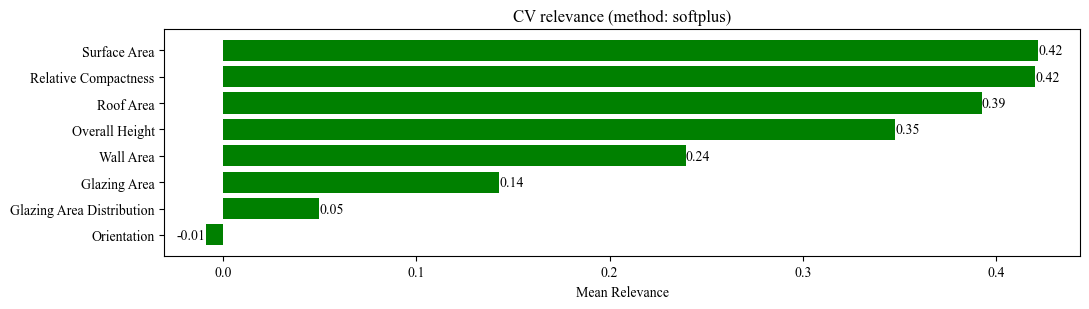

In [4]:
print_cv_relevance(softplus_results, X.columns)
plot_cv_relevance(softplus_results, X.columns)

In [ ]:
from src.cv import cv_relevance, print_cv_relevance, plot_cv_relevance
param_softplus_results = cv_relevance(X, y,
                                      N_feature=4, N_target=4,
                                      method="softplus", a=3., b=100.)

CV Relevance Results (method: param-softplus):

Feature: Relative Compactness
  per fold: [0.53 0.64 0.7  0.62 0.61 0.7  0.39 0.74 0.57 0.6 ]
  mean relevance : 0.6087
  std relevance  : 0.0956

Feature: Surface Area
  per fold: [0.49 0.67 0.71 0.59 0.6  0.73 0.45 0.75 0.55 0.62]
  mean relevance : 0.6151
  std relevance  : 0.0947

Feature: Wall Area
  per fold: [-0.09 -0.09  0.05  0.12  0.39 -0.05 -0.1   0.25  0.28  0.05]
  mean relevance : 0.0801
  std relevance  : 0.1663

Feature: Roof Area
  per fold: [0.5  0.62 0.67 0.54 0.67 0.57 0.37 0.67 0.52 0.55]
  mean relevance : 0.5686
  std relevance  : 0.0924

Feature: Overall Height
  per fold: [0.47 0.5  0.57 0.45 0.56 0.48 0.3  0.56 0.51 0.45]
  mean relevance : 0.4842
  std relevance  : 0.0734

Feature: Orientation
  per fold: [-0.07 -0.08 -0.04 -0.07 -0.07 -0.06 -0.03 -0.02 -0.05 -0.02]
  mean relevance : -0.0507
  std relevance  : 0.0206

Feature: Glazing Area
  per fold: [-0.01  0.01  0.11 -0.08  0.16  0.09 -0.02 -0.13  0.1  -0.21

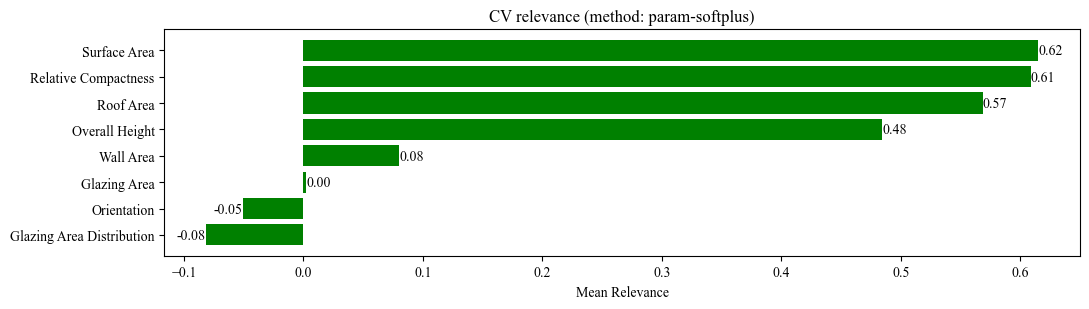

In [6]:
print_cv_relevance(param_softplus_results, X.columns, method="param-softplus")
plot_cv_relevance(param_softplus_results, X.columns, method="param-softplus")

In [ ]:
from src.cv import cv_relevance, print_cv_relevance, plot_cv_relevance
clip_results = cv_relevance(X, y,
                            N_feature=4, N_target=4,
                            method="clip")

CV Relevance Results (method: clip):

Feature: Relative Compactness
  per fold: [0.43 0.62 0.65 0.29 0.46 0.65 0.51 0.67 0.57 0.61]
  mean relevance : 0.5453
  std relevance  : 0.1163

Feature: Surface Area
  per fold: [0.42 0.63 0.64 0.29 0.45 0.65 0.53 0.66 0.57 0.61]
  mean relevance : 0.5456
  std relevance  : 0.1181

Feature: Wall Area
  per fold: [0.09 0.18 0.23 0.02 0.27 0.23 0.21 0.38 0.41 0.29]
  mean relevance : 0.2306
  std relevance  : 0.1114

Feature: Roof Area
  per fold: [0.57 0.59 0.63 0.59 0.65 0.59 0.52 0.64 0.57 0.59]
  mean relevance : 0.5926
  std relevance  : 0.0363

Feature: Overall Height
  per fold: [0.55 0.56 0.58 0.55 0.58 0.56 0.5  0.58 0.57 0.55]
  mean relevance : 0.5573
  std relevance  : 0.0246

Feature: Orientation
  per fold: [-0.02 -0.03 -0.01 -0.02 -0.02 -0.02 -0.01 -0.01 -0.02 -0.01]
  mean relevance : -0.0169
  std relevance  : 0.0072

Feature: Glazing Area
  per fold: [0.19 0.19 0.21 0.18 0.26 0.25 0.21 0.15 0.24 0.1 ]
  mean relevance : 0.1982
  

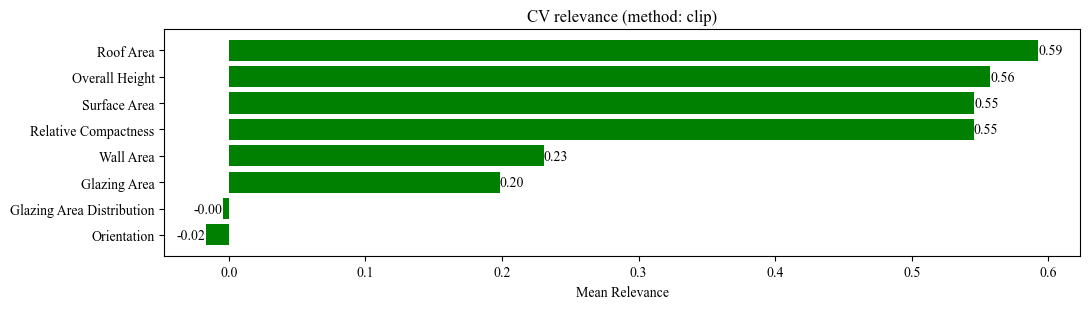

In [8]:
print_cv_relevance(clip_results, X.columns, method="clip")
plot_cv_relevance(clip_results, X.columns, method="clip")

In [11]:
from src.evaluation import relevance_to_df
relevance_df = relevance_to_df(softplus_results,
                               param_softplus_results,
                               clip_results)
relevance_df

softplus           param_softplus            \
                               mean       std           mean       std   
feature                                                                  
Relative Compactness       0.420363  0.023356       0.608727  0.095587   
Surface Area               0.421920  0.022628       0.615116  0.094656   
Wall Area                  0.239524  0.041705       0.080052  0.166314   
Roof Area                  0.392528  0.023630       0.568646  0.092445   
Overall Height             0.347781  0.016921       0.484237  0.073369   
Orientation               -0.008923  0.003779      -0.050706  0.020612   
Glazing Area               0.142910  0.037164       0.002339  0.112146   
Glazing Area Distribution  0.049784  0.023511      -0.081714  0.071028   

                               clip            
                               mean       std  
feature                                        
Relative Compactness       0.545263  0.116267  
Surface Area               0.545602  0.118086  
Wall Area                  0.230575  0.111415  
Roof Area                  0.592601  0.036276  
Overall Height             0.557276  0.024583  
Orientation               -0.016859  0.007232  
Glazing Area               0.198212  0.045379  
Glazing Area Distribution -0.004506  0.112876

 ### Relevance (feature deg. 7, target deg. 7)

In [ ]:
from src.evaluation import relevance, report_relevance

columns_relevance_higher_degs = {}
for col in X.columns:
    print(f"--- Evaluating relevance for feature: {col} ---")

    softplus_relevance = relevance(X_train_norm, X_test_norm,
                                   y_train_norm, y_test_norm,
                                   col, y_test, y_denorm,   
                                   N_feature=7, N_target=7)
    
    param_softplus_relevance = relevance(X_train_norm, X_test_norm,
                                         y_train_norm, y_test_norm,
                                         col, y_test, y_denorm,
                                         N_feature=7, N_target=7,
                                         method="softplus", a=3., b=100.)

    clip_relevance = relevance(X_train_norm, X_test_norm,
                               y_train_norm, y_test_norm,
                               col, y_test, y_denorm,  
                               N_feature=7, N_target=7,
                               method="clip")
    
    columns_relevance_higher_degs[col] = {
        "softplus": softplus_relevance,
        "param-softplus": param_softplus_relevance,
        "clip": clip_relevance
    }

In [16]:
report_relevance(columns_relevance_higher_degs, method="softplus")

Feature Relevance Ranking (method: softplus):
1. Relative Compactness: 0.6058
2. Surface Area: 0.5989
3. Roof Area: 0.4192
4. Wall Area: 0.3814
5. Overall Height: 0.3668
6. Glazing Area: 0.2528
7. Glazing Area Distribution: 0.0908
8. Orientation: -0.0146


In [17]:
report_relevance(columns_relevance_higher_degs, method="param-softplus")

Feature Relevance Ranking (method: param-softplus):
1. Relative Compactness: 0.8362
2. Surface Area: 0.8348
3. Overall Height: 0.5491
4. Roof Area: 0.4656
5. Wall Area: 0.3982
6. Glazing Area: 0.0139
7. Glazing Area Distribution: -0.0063
8. Orientation: -0.0828


In [18]:
report_relevance(columns_relevance_higher_degs, method="clip")

Feature Relevance Ranking (method: clip):
1. Relative Compactness: 0.6755
2. Surface Area: 0.6752
3. Roof Area: 0.6559
4. Overall Height: 0.6036
5. Wall Area: 0.5502
6. Glazing Area: 0.3228
7. Glazing Area Distribution: 0.0911
8. Orientation: -0.0280


In [19]:
import pandas as pd

df_relevance = pd.DataFrame.from_dict(
    columns_relevance_higher_degs,
    orient="index"
)
df_relevance

,softplus,param-softplus,clip
Relative Compactness,0.605801,0.836248,0.675542
Surface Area,0.598950,0.834810,0.675172
Wall Area,0.381363,0.398242,0.550250
Roof Area,0.419238,0.465602,0.655887
Overall Height,0.366784,0.549137,0.603620
Orientation,-0.014637,-0.082787,-0.027965
Glazing Area,0.252826,0.013874,0.322846
Glazing Area Distribution,0.090795,-0.006297,0.091086


 ### CV for relevance (feature deg. 7, target deg. 7)

In [ ]:
from src.cv import cv_relevance, print_cv_relevance, plot_cv_relevance
softplus_results_higher_degs = cv_relevance(X, y,
                                            N_feature=7, N_target=7)

CV Relevance Results (method: softplus):

Feature: Relative Compactness
  per fold: [0.58 0.6  0.64 0.65 0.63 0.6  0.58 0.62 0.58 0.61]
  mean relevance : 0.6091
  std relevance  : 0.0243

Feature: Surface Area
  per fold: [0.59 0.58 0.63 0.59 0.58 0.59 0.55 0.63 0.54 0.6 ]
  mean relevance : 0.5889
  std relevance  : 0.0261

Feature: Wall Area
  per fold: [0.41 0.37 0.36 0.41 0.42 0.35 0.31 0.39 0.37 0.34]
  mean relevance : 0.3741
  std relevance  : 0.0343

Feature: Roof Area
  per fold: [0.41 0.43 0.46 0.41 0.5  0.4  0.4  0.45 0.43 0.43]
  mean relevance : 0.4334
  std relevance  : 0.0293

Feature: Overall Height
  per fold: [0.35 0.38 0.39 0.38 0.38 0.38 0.33 0.37 0.38 0.35]
  mean relevance : 0.3694
  std relevance  : 0.0173

Feature: Orientation
  per fold: [-0.02 -0.02 -0.01 -0.02 -0.02 -0.02 -0.01 -0.01 -0.02 -0.01]
  mean relevance : -0.0145
  std relevance  : 0.0046

Feature: Glazing Area
  per fold: [0.2  0.28 0.26 0.17 0.27 0.32 0.24 0.19 0.26 0.16]
  mean relevance : 0.235

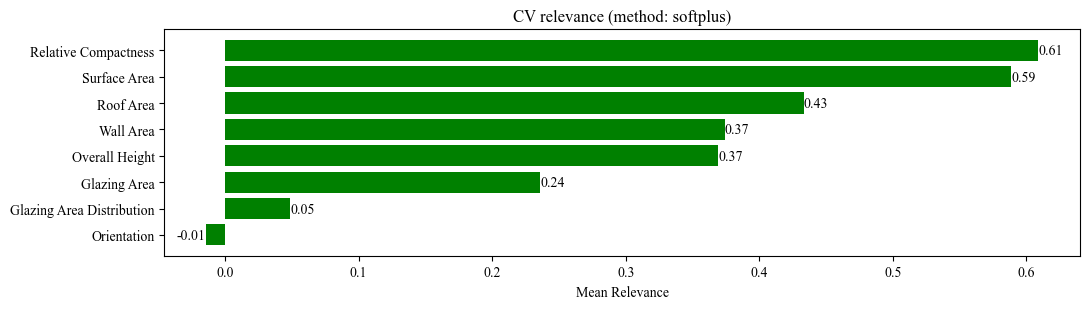

In [13]:
print_cv_relevance(softplus_results_higher_degs, X.columns)
plot_cv_relevance(softplus_results_higher_degs, X.columns)

In [ ]:
from src.cv import cv_relevance, print_cv_relevance, plot_cv_relevance
param_softplus_results_higher_degs = cv_relevance(X, y,
                                                  N_feature=7, N_target=7,
                                                  method="softplus", a=3., b=100.)

CV Relevance Results (method: param-softplus):

Feature: Relative Compactness
  per fold: [0.67 0.8  0.95 0.92 0.88 0.78 0.68 0.83 0.69 0.84]
  mean relevance : 0.8017
  std relevance  : 0.0956

Feature: Surface Area
  per fold: [0.72 0.77 0.93 0.71 0.71 0.78 0.55 0.89 0.56 0.79]
  mean relevance : 0.7403
  std relevance  : 0.1152

Feature: Wall Area
  per fold: [0.39 0.37 0.32 0.48 0.47 0.24 0.04 0.43 0.26 0.22]
  mean relevance : 0.3205
  std relevance  : 0.1275

Feature: Roof Area
  per fold: [0.44 0.62 0.72 0.48 0.71 0.51 0.38 0.59 0.53 0.54]
  mean relevance : 0.5538
  std relevance  : 0.1047

Feature: Overall Height
  per fold: [0.48 0.6  0.64 0.6  0.6  0.6  0.36 0.56 0.59 0.49]
  mean relevance : 0.5518
  std relevance  : 0.0781

Feature: Orientation
  per fold: [-0.09 -0.11 -0.05 -0.1  -0.09 -0.13 -0.05 -0.05 -0.1  -0.07]
  mean relevance : -0.0829
  std relevance  : 0.0250

Feature: Glazing Area
  per fold: [-0.19  0.28  0.22 -0.33  0.13  0.2   0.   -0.09  0.06 -0.2 ]
  mean r

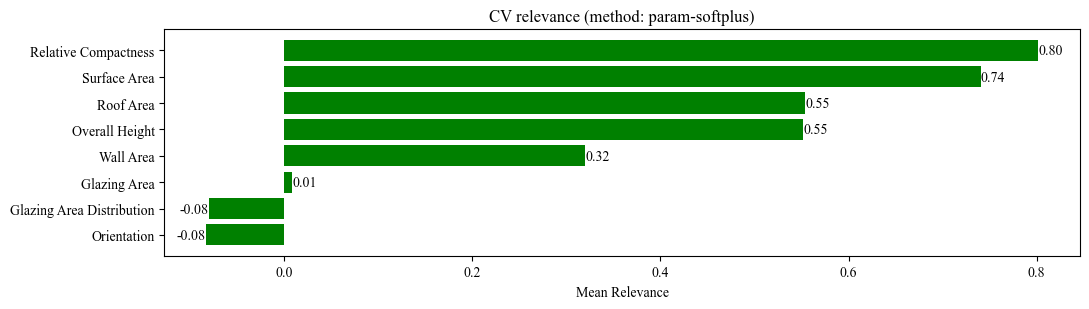

In [15]:
print_cv_relevance(param_softplus_results_higher_degs, X.columns, method="param-softplus")
plot_cv_relevance(param_softplus_results_higher_degs, X.columns, method="param-softplus")

In [ ]:
from src.cv import cv_relevance, print_cv_relevance, plot_cv_relevance
clip_results_higher_degs = cv_relevance(X, y,
                                        N_feature=7, N_target=7,
                                        method="clip")

CV Relevance Results (method: clip):

Feature: Relative Compactness
  per fold: [0.79 0.82 0.87 0.88 0.87 0.81 0.78 0.86 0.77 0.85]
  mean relevance : 0.8294
  std relevance  : 0.0397

Feature: Surface Area
  per fold: [0.81 0.65 0.87 0.82 0.81 0.77 0.7  0.88 0.57 0.83]
  mean relevance : 0.7699
  std relevance  : 0.0967

Feature: Wall Area
  per fold: [0.59 0.36 0.51 0.58 0.44 0.5  0.4  0.57 0.5  0.32]
  mean relevance : 0.4775
  std relevance  : 0.0882

Feature: Roof Area
  per fold: [0.63 0.67 0.72 0.66 0.75 0.63 0.61 0.7  0.65 0.67]
  mean relevance : 0.6684
  std relevance  : 0.0431

Feature: Overall Height
  per fold: [0.58 0.61 0.63 0.62 0.62 0.61 0.53 0.61 0.62 0.58]
  mean relevance : 0.6014
  std relevance  : 0.0279

Feature: Orientation
  per fold: [-0.03 -0.04 -0.02 -0.03 -0.03 -0.04 -0.02 -0.02 -0.03 -0.02]
  mean relevance : -0.0279
  std relevance  : 0.0091

Feature: Glazing Area
  per fold: [0.04 0.39 0.37 0.2  0.38 0.37 0.33 0.24 0.35 0.17]
  mean relevance : 0.2854
  

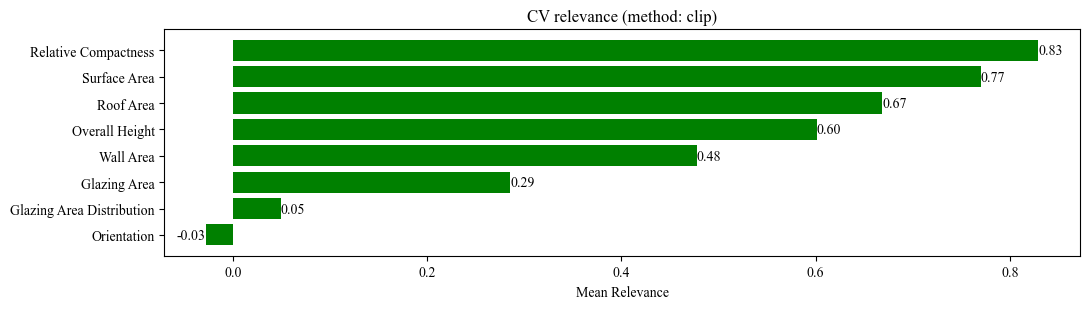

In [17]:
print_cv_relevance(clip_results_higher_degs, X.columns, method="clip")
plot_cv_relevance(clip_results_higher_degs, X.columns, method="clip")

In [18]:
from src.evaluation import relevance_to_df
relevance_df = relevance_to_df(softplus_results_higher_degs,
                               param_softplus_results_higher_degs,
                               clip_results_higher_degs)
relevance_df

softplus           param_softplus            \
                               mean       std           mean       std   
feature                                                                  
Relative Compactness       0.609067  0.024330       0.801736  0.095632   
Surface Area               0.588908  0.026085       0.740265  0.115217   
Wall Area                  0.374090  0.034349       0.320515  0.127460   
Roof Area                  0.433404  0.029293       0.553832  0.104682   
Overall Height             0.369432  0.017310       0.551775  0.078125   
Orientation               -0.014521  0.004635      -0.082896  0.025039   
Glazing Area               0.235927  0.050287       0.009106  0.195352   
Glazing Area Distribution  0.048594  0.033337      -0.080028  0.074416   

                               clip            
                               mean       std  
feature                                        
Relative Compactness       0.829399  0.039651  
Surface Area               0.769892  0.096713  
Wall Area                  0.477500  0.088204  
Roof Area                  0.668391  0.043074  
Overall Height             0.601370  0.027921  
Orientation               -0.027914  0.009088  
Glazing Area               0.285436  0.109314  
Glazing Area Distribution  0.048999  0.042198